In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/job-salary-prediction-dataset/job_salary_prediction_dataset.csv")

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.shape

(250000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
print("Total Job Role",len(df['job_title'].unique()))  # Find Total Job Role


Total Job Role 12


# Average Salary

In [8]:
print("Total Average Salary",np.average(df['salary']))

Total Average Salary 145718.080524


# Average Salary of Each Job Role

In [9]:
df.groupby('job_title')['salary'].mean().sort_values(ascending=False)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Business Analyst             122551.231354
Data Analyst                 119891.696603
Name: salary, dtype: float64

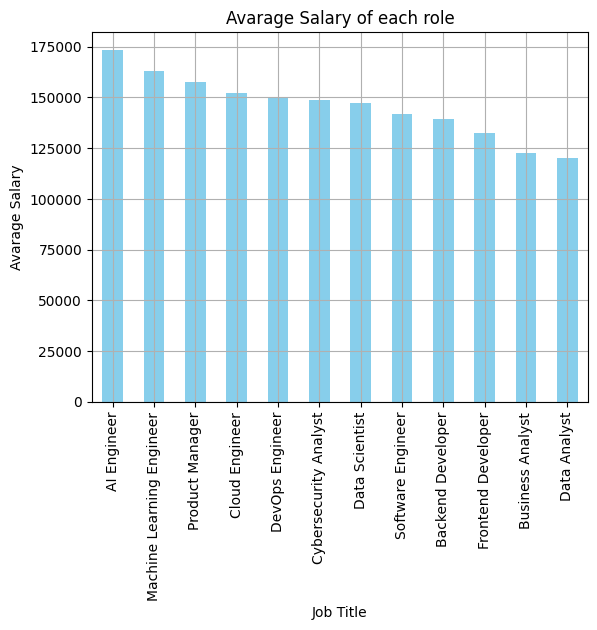

In [10]:
average_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
average_salary.plot(kind = 'bar',color = 'skyblue')
plt.xlabel("Job Title")
plt.ylabel("Avarage Salary")
plt.title('Avarage Salary of each role')
plt.grid(True)
plt.show()

In [11]:
print('AI Engineer Have High Salary: ',173498.480640)
print('Data Analyst have low Salary: ',119891.696603)

AI Engineer Have High Salary:  173498.48064
Data Analyst have low Salary:  119891.696603


# Check Education Level

In [12]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [13]:
df['education_level'].value_counts()

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

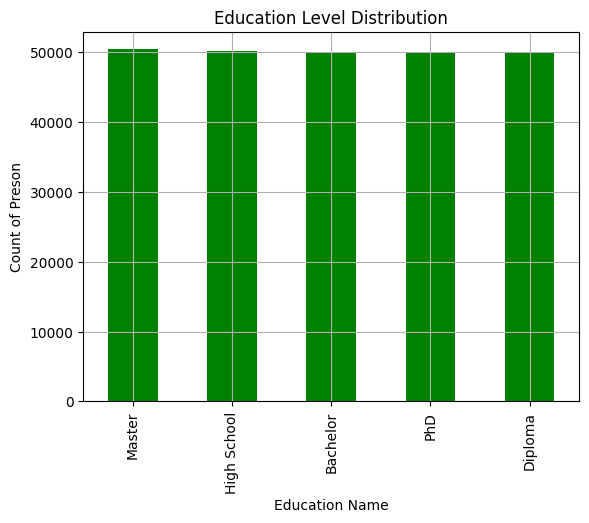

In [14]:
education_level = df['education_level'].value_counts()
education_level.plot(kind= 'bar',color= 'green')
plt.xlabel('Education Name')
plt.ylabel("Count of Preson")
plt.title('Education Level Distribution')
plt.grid(True)
plt.show()

In [15]:
print('Master Level Education is High: ',50352)
print('Diploma Level Education is  Low: ',49776)
print("All Education level is  cloeset ot each other")
df['education_level'].value_counts()

Master Level Education is High:  50352
Diploma Level Education is  Low:  49776
All Education level is  cloeset ot each other


education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

# Remote vs On-site vs Hybrid salary comparison

In [16]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [17]:
salary_comparison = df.groupby('remote_work')['salary'].mean()
print(salary_comparison)

remote_work
Hybrid    143969.899839
No        143932.300941
Yes       149279.589822
Name: salary, dtype: float64


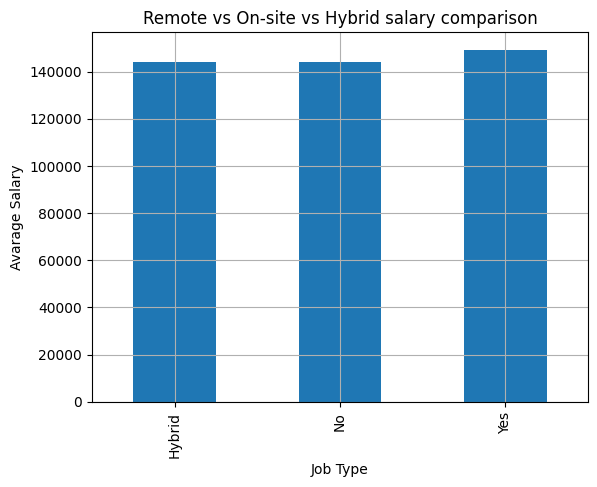

In [18]:
salary_comparison.plot(kind = 'bar')
plt.xlabel("Job Type")
plt.ylabel("Avarage Salary")
plt.title('Remote vs On-site vs Hybrid salary comparison')
plt.grid(True)
plt.show()

In [19]:
print("After Saw Bar Plot hear Remote Job type has High Salary\nand Lovest Job type On-site\n")
salary_comparison = df.groupby('remote_work')['salary'].mean()
print(salary_comparison)

After Saw Bar Plot hear Remote Job type has High Salary
and Lovest Job type On-site

remote_work
Hybrid    143969.899839
No        143932.300941
Yes       149279.589822
Name: salary, dtype: float64


# Which one Industy Gaining Highest Salary in this data

In [20]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


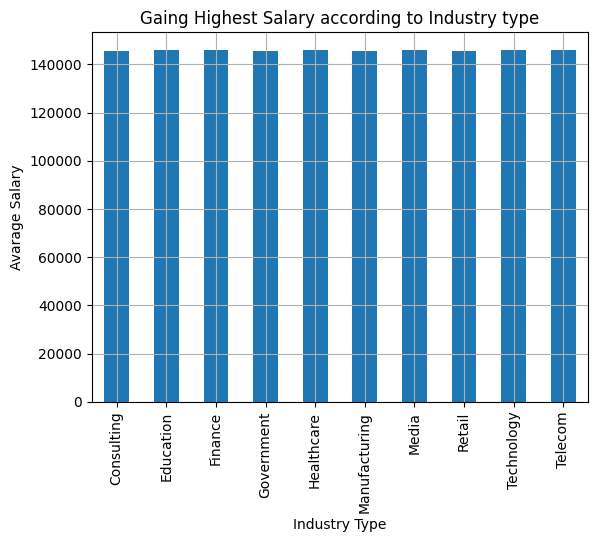

In [21]:
salary_industry = df.groupby('industry')['salary'].mean()
salary_industry.plot(kind = 'bar')
plt.xlabel("Industry Type")
plt.ylabel('Avarage Salary')
plt.title("Gaing Highest Salary according to Industry type")
plt.grid(True)
plt.show()

In [22]:
print(df.groupby('industry')['salary'].mean())
print('\nTelecom Industry has high salary: 145876.511967\nand Lowest Consulting Industry has low salary: 145451.638293')

industry
Consulting       145451.638293
Education        145993.564547
Finance          145801.639468
Government       145613.869242
Healthcare       145759.995702
Manufacturing    145530.603301
Media            145891.271071
Retail           145399.699408
Technology       145863.808377
Telecom          145876.511967
Name: salary, dtype: float64

Telecom Industry has high salary: 145876.511967
and Lowest Consulting Industry has low salary: 145451.638293


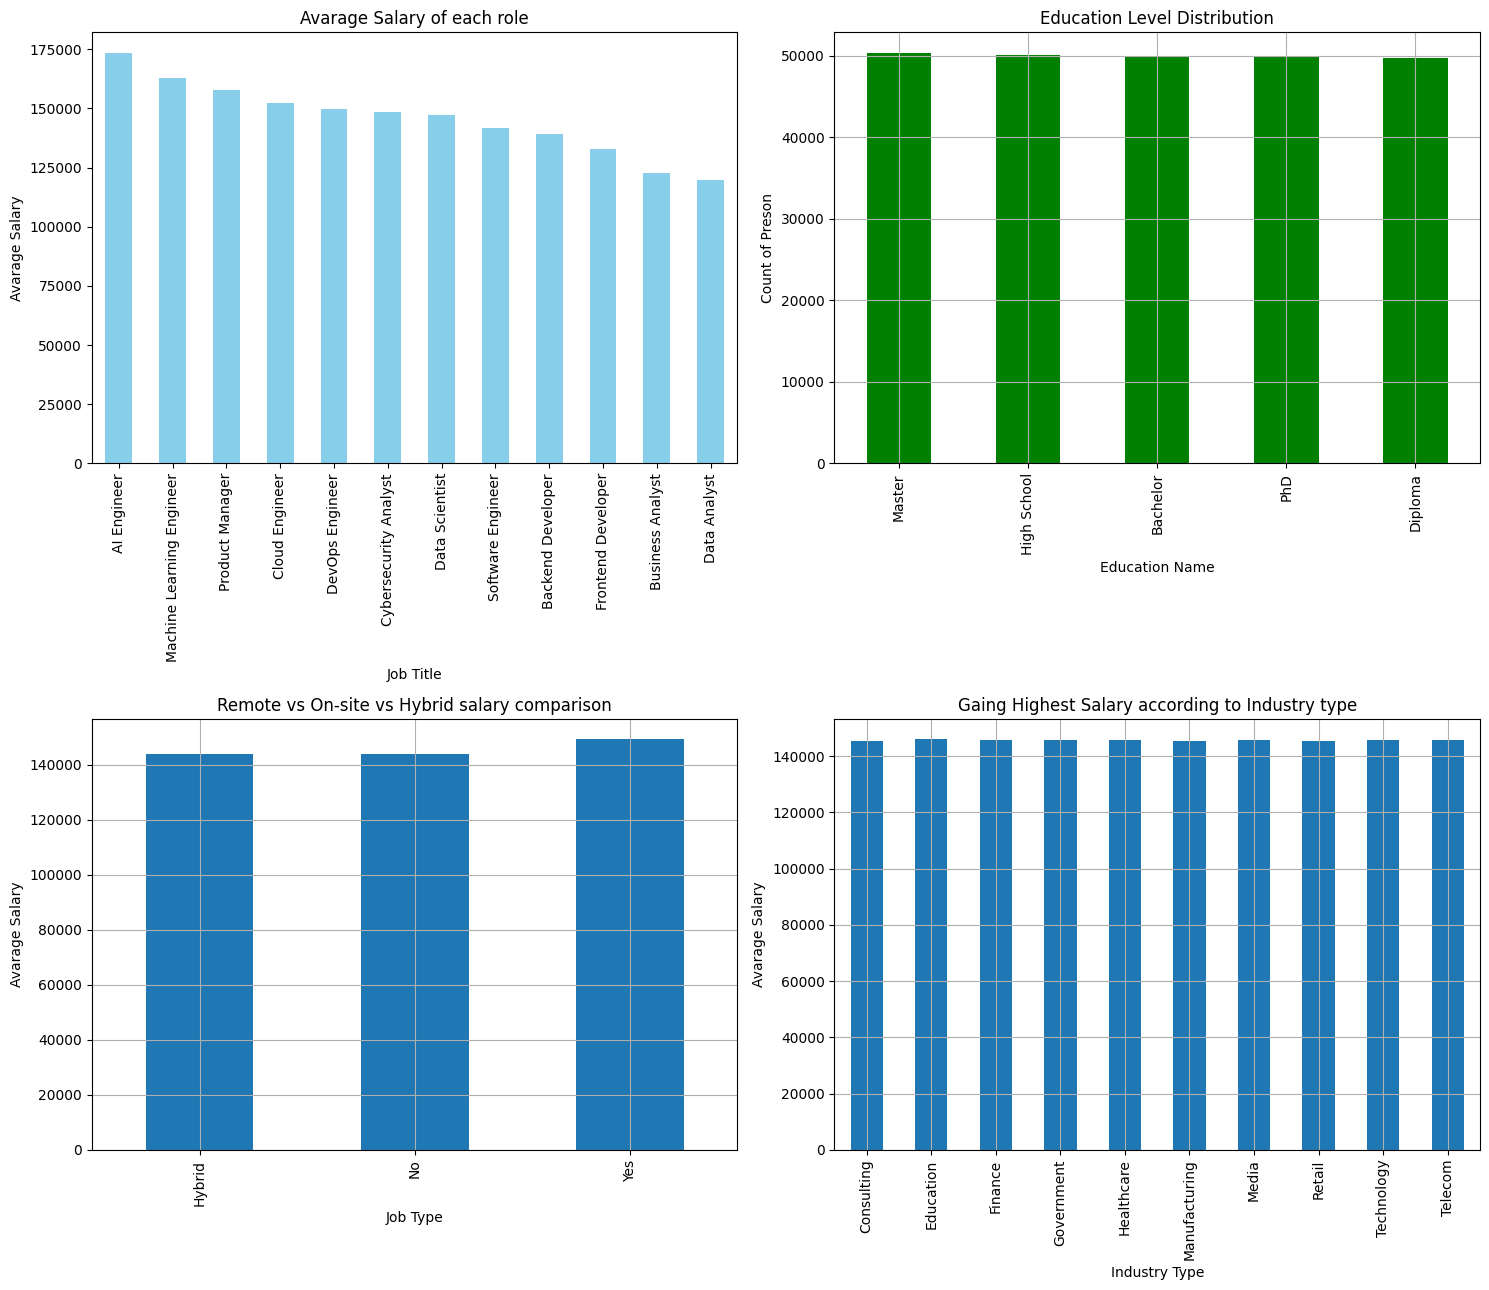

In [23]:
plt.figure(figsize=(15,13))
# 1st Plot
plt.subplot(2,2,1)
average_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
average_salary.plot(kind = 'bar',color = 'skyblue')
plt.xlabel("Job Title")
plt.ylabel("Avarage Salary")
plt.title('Avarage Salary of each role')



#2nd Plot
plt.subplot(2,2,2)

education_level = df['education_level'].value_counts()
education_level.plot(kind= 'bar',color= 'green')
plt.xlabel('Education Name')
plt.ylabel("Count of Preson")
plt.title('Education Level Distribution')
plt.grid(True)


#3rd plot
plt.subplot(2,2,3)

salary_comparison.plot(kind = 'bar')
plt.xlabel("Job Type")
plt.ylabel("Avarage Salary")
plt.title('Remote vs On-site vs Hybrid salary comparison')
plt.grid(True)


#4th plot
plt.subplot(2,2,4)
salary_industry = df.groupby('industry')['salary'].mean()
salary_industry.plot(kind = 'bar')
plt.xlabel("Industry Type")
plt.ylabel('Avarage Salary')
plt.title("Gaing Highest Salary according to Industry type")
plt.grid(True)

plt.tight_layout()
plt.show()
